In [1]:
%%bash
python3 -m venv /opt/gpflow_env --without-pip
curl -sS https://bootstrap.pypa.io/get-pip.py | /opt/gpflow_env/bin/python3
/opt/gpflow_env/bin/pip install -q --upgrade pip setuptools wheel
/opt/gpflow_env/bin/pip install -q tensorflow==2.16.2 tensorflow-probability==0.24.0 gpflow==2.9.2 gpflux==0.4.4 numpy==1.26.4 scikit-learn matplotlib pandas scipy
echo "Setup OK"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.0 MB/s  0:00:00
Setup OK


In [4]:
%%bash
cat > /opt/gpflow_env/lib/python3.12/site-packages/gpflow/versions.py << 'EOF'
from importlib.metadata import version, PackageNotFoundError
try:
    __version__ = version("gpflow")
except PackageNotFoundError:
    __version__ = "unknown"
EOF

MPLBACKEND=Agg TF_USE_LEGACY_KERAS=1 /opt/gpflow_env/bin/python3 -c "import gpflow; print('gpflow OK:', gpflow.__version__)"

gpflow OK: 2.9.2


2026-05-25 20:57:05.169615: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 20:57:05.175041: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 20:57:05.196261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-25 20:57:05.241481: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-25 20:57:05.241548: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-25 20:57:05.265274: I tensorflow/core/platform/cpu_feature_guard.cc:

In [18]:
import os
os.remove("/tmp/run_gpflow_2d.py")
print("Script viejo eliminado")

Script viejo eliminado


In [19]:
script = r"""
import os
os.environ['MPLBACKEND'] = 'Agg'
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tensorflow as tf
import gpflow as gpf
import gpflux
from gpflow.quadrature.deprecated import ndiagquad, ndiag_mc
from check_shapes import inherit_check_shapes
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from scipy.spatial.distance import cdist

gpf.config.set_default_float(np.float64)
np.random.seed(0)

# ============================================================
# 1. Generación de datos
# ============================================================
K   = 2
Nk  = 50

mu1, mu2 = np.array([3.,  3.]),  np.array([3., -3.])
mu3, mu4 = np.array([-3.,-3.]), np.array([-3.,  3.])
Cov = np.array([[0.8, 0.1],[0.1, 0.9]])

np.random.seed(0)
X1 = np.random.multivariate_normal(mu1, Cov, Nk)
X3 = np.random.multivariate_normal(mu3, Cov, Nk)
X2 = np.random.multivariate_normal(mu2, Cov, Nk)
X4 = np.random.multivariate_normal(mu4, Cov, Nk)

X = np.vstack([X1, X3, X2, X4])
y = np.hstack([np.zeros(2*Nk), np.ones(2*Nk)])
N = X.shape[0]
print(f"N={N}")

scaler = StandardScaler()
Xtrain = scaler.fit_transform(X).astype(np.float64)
ytrain = (y + 1).reshape(-1,1)

# ============================================================
# 2. Anotadores
# ============================================================
R = 5
pflip = np.array([
    [0.00, 0.90, 0.50, 0.15, 0.60],
    [0.90, 0.00, 0.30, 0.40, 0.75],
    [0.50, 0.30, 0.00, 0.60, 0.30],
    [0.15, 0.40, 0.60, 0.00, 0.80],
    [0.60, 0.75, 0.30, 0.80, 0.00]
])

np.random.seed(0)
kmeans = KMeans(n_clusters=R, random_state=0, n_init=10).fit(Xtrain)
idxK = kmeans.labels_

Ytrain = np.zeros((N, R))
for r in range(R):
    yr = y.copy()
    for k in range(R):
        auxidx = np.where(idxK == k)[0]
        aux = np.random.binomial(1, pflip[k, r], len(auxidx))
        yr[auxidx[aux == 1]] = 1 - y[auxidx[aux == 1]]
    Ytrain[:,r] = yr + 1

print("Accuracy por anotador:")
for r in range(R):
    print(f"  Anotador {r+1}: {np.mean((Ytrain[:,r]-1)==y)*100:.1f}%")

Ytrain = Ytrain.astype(np.float64)

# ============================================================
# 3. Test set — grid en espacio ORIGINAL luego normalizado
# ============================================================
x1g = np.linspace(-6, 6, 50)
x2g = np.linspace(-6, 6, 50)
xx1_orig, xx2_orig = np.meshgrid(x1g, x2g)
Xtest_orig = np.column_stack([xx1_orig.ravel(), xx2_orig.ravel()])
Xtest = scaler.transform(Xtest_orig).astype(np.float64)

cent_c0 = np.vstack([mu1, mu3])
cent_c1 = np.vstack([mu2, mu4])
d0 = cdist(Xtest_orig, cent_c0).min(axis=1)
d1 = cdist(Xtest_orig, cent_c1).min(axis=1)
ytest = ((d1 < d0).astype(float) + 1).reshape(-1,1).astype(np.float64)
Ntest = Xtest.shape[0]
print(f"Ntest={Ntest}")

# ============================================================
# 4. Likelihood
# ============================================================
class multiClassMA(gpf.likelihoods.Likelihood):
    def __init__(self, num_classes, num_ann):
        super().__init__(input_dim=None, latent_dim=num_classes+num_ann, observation_dim=None)
        self.K = num_classes
        self.R = num_ann

    @inherit_check_shapes
    def _log_prob(self, X, F, Y):
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        zeta = tf.repeat(tf.expand_dims(tf.nn.softmax(F[:,:self.K]), axis=-1), self.R, axis=-1)
        lamb = tf.nn.sigmoid(F[:,self.K:])
        CE   = tf.math.reduce_sum(Yh * tf.math.log(zeta + 1e-10), axis=1)
        return tf.math.reduce_sum(iAnn * (lamb*CE - (1-lamb)*np.log(self.K)), axis=1)

    def _variational_expectations(self, X, Fmu, Fvar, Y):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        Elog  = ndiag_mc(self.log_softmax, 800, m_f, v_f, False)
        Elog_ = tf.repeat(tf.expand_dims(Elog, axis=-1), self.R, axis=-1)
        C_E   = tf.math.reduce_sum(Yh * Elog_, axis=1)
        Eq_g  = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        return tf.math.reduce_sum(iAnn * (Eq_g*C_E - (1-Eq_g)*np.log(self.K)), axis=1)

    def _predict_mean_and_var(self, X, Fmu, Fvar):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        Ez   = ndiag_mc(tf.nn.softmax, 800, m_f, v_f, False)
        El   = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        Ez_2 = ndiag_mc(self.softmax_2, 800, m_f, v_f, False)
        El_2 = ndiagquad(self.sigmoid_2, 20, m_g, v_g, False)
        return tf.concat([Ez, El], axis=1), tf.concat([Ez_2-Ez**2, El_2-El**2], axis=1)

    def _predict_log_density(self, F):
        raise NotImplementedError

    def log_softmax(self, F):
        return tf.math.log(tf.nn.softmax(F) + 1e-10)

    def softmax_2(self, F):
        return tf.math.square(tf.nn.softmax(F))

    def sigmoid_2(self, F):
        return tf.math.square(tf.nn.sigmoid(F))

# ============================================================
# 5. Modelo — UNA SOLA CAPA GP
#    input 2D → output (K+R)=7D directamente
# ============================================================
M = 25
L = K + R  # 7

# Inducing points: grid uniforme 5x5 en espacio normalizado
g = np.linspace(-2, 2, 5)
gx, gy = np.meshgrid(g, g)
Z = np.column_stack([gx.ravel(), gy.ravel()]).astype(np.float64)  # (25, 2)

kernel = gpf.kernels.SquaredExponential(
    variance=1.0, lengthscales=np.array([1.0, 1.0])
)
inducing = gpf.inducing_variables.InducingPoints(Z.copy())
gp_layer = gpflux.layers.GPLayer(
    kernel, inducing,
    num_data=N,
    num_latent_gps=L,
    mean_function=gpf.mean_functions.Zero()
)

likelihood_layer = gpflux.layers.LikelihoodLayer(multiClassMA(K, R))
dgp = gpflux.models.DeepGP(
    f_layers=[gp_layer],
    likelihood=likelihood_layer,
    input_dim=2
)
model = dgp.as_training_model()
model.compile(gpf.keras.tf_keras.optimizers.Adam(0.01))
print(f"\nModelo: 1 capa GP  |  M={M}  |  L={L}  |  input_dim=2")

# ============================================================
# 6. Entrenamiento
# ============================================================
history = model.fit(
    {"inputs": Xtrain, "targets": Ytrain},
    batch_size=50,
    epochs=3000,
    verbose=1
)

# ============================================================
# 7. Predicciones y métricas
# ============================================================
f_dist = model({"inputs": Xtest, "targets": ytest})
pY  = f_dist.y_mean.numpy()
pYv = f_dist.y_var.numpy()

Yhat_test = np.zeros((Ntest, K))
for k in range(K):
    Yhat_test[:,k] = (ytest.flatten() == k+1).astype(float)

pred_class = np.argmax(pY[:,:K], axis=1) + 1
acc  = accuracy_score(ytest.flatten(), pred_class)
auc  = roc_auc_score(Yhat_test, pY[:,:K])
nmi  = normalized_mutual_info_score(ytest.flatten(), pred_class)
print(f"\nAcc={acc*100:.2f}%  AUC={auc*100:.2f}%  NMI={nmi*100:.2f}%")

# ============================================================
# 8. Guardar
# ============================================================
np.save("/tmp/pY.npy",           pY)
np.save("/tmp/pYv.npy",          pYv)
np.save("/tmp/Xtest.npy",        Xtest)
np.save("/tmp/Xtrain.npy",       Xtrain)
np.save("/tmp/ytest.npy",        ytest)
np.save("/tmp/Ytrain.npy",       Ytrain)
np.save("/tmp/history_loss.npy", np.array(history.history["loss"]))
np.save("/tmp/xx1.npy",          xx1_orig)
np.save("/tmp/xx2.npy",          xx2_orig)
np.save("/tmp/metrics.npy",      np.array([acc, auc, nmi]))
np.save("/tmp/X.npy",            X)
np.save("/tmp/y.npy",            y)

# ============================================================
# 9. Plots — usando coordenadas ORIGINALES
# ============================================================
Xorig = scaler.inverse_transform(Xtrain)

plt.figure()
plt.plot(history.history['loss'])
plt.title('Model loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.savefig('/tmp/training_loss.png', dpi=150, bbox_inches='tight')
plt.close()

fig, axes = plt.subplots(2, 4, figsize=(22, 11))

def plot_scatter(ax):
    ax.scatter(Xorig[y==0,0], Xorig[y==0,1], c='red',  marker='x', s=40, zorder=5, label='Clase 0')
    ax.scatter(Xorig[y==1,0], Xorig[y==1,1], c='blue', marker='^', s=40, zorder=5, label='Clase 1')
    ax.set_xlim(-6.5, 6.5); ax.set_ylim(-6.5, 6.5)

# --- [0,0] Predicción de clase ---
ax = axes[0,0]
prob_c2 = pY[:,1].reshape(xx1_orig.shape)
cp = ax.contourf(xx1_orig, xx2_orig, prob_c2, levels=20, cmap='RdBu_r', alpha=0.85)
ax.contour(xx1_orig, xx2_orig, prob_c2, levels=[0.5], colors='k', linewidths=2)
plot_scatter(ax)
ax.set_title(f'GP MA — P(clase 2)\nAcc={acc*100:.1f}%  AUC={auc*100:.1f}%')
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(cp, ax=ax)

# --- λ1 a λ5 en posiciones explícitas ---
ann_positions = [(0,1),(0,2),(0,3),(1,0),(1,1)]
for r, (row, col) in enumerate(ann_positions):
    ax = axes[row, col]
    lam_r = pY[:, K+r].reshape(xx1_orig.shape)
    cp = ax.contourf(xx1_orig, xx2_orig, lam_r, levels=20,
                     cmap='viridis', alpha=0.85, vmin=0, vmax=1)
    ax.contour(xx1_orig, xx2_orig, lam_r, levels=[0.5], colors='w', linewidths=1)
    plot_scatter(ax)
    ann_acc = np.mean((Ytrain[:,r]-1) == y)
    ax.set_title(f'$\\lambda_{r+1}$  (acc anotador={ann_acc*100:.0f}%)')
    plt.colorbar(cp, ax=ax)

# --- [1,2] Ground truth ---
ax = axes[1,2]
ax.scatter(Xorig[y==0,0], Xorig[y==0,1], c='red',  marker='x', s=60, zorder=5, label='Clase 0')
ax.scatter(Xorig[y==1,0], Xorig[y==1,1], c='blue', marker='^', s=60, zorder=5, label='Clase 1')
ax.set_xlim(-6.5, 6.5); ax.set_ylim(-6.5, 6.5)
ax.set_title('Ground truth')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- [1,3] Varianza predictiva ---
ax = axes[1,3]
var_c2 = np.abs(pYv[:,1]).reshape(xx1_orig.shape)
cp = ax.contourf(xx1_orig, xx2_orig, var_c2, levels=20, cmap='hot_r', alpha=0.85)
plot_scatter(ax)
ax.set_title('Varianza predictiva')
plt.colorbar(cp, ax=ax)

plt.suptitle(f'GP MA 2D  |  Acc={acc*100:.2f}%  AUC={auc*100:.2f}%  NMI={nmi*100:.2f}%',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/resultados_2d.png', dpi=150, bbox_inches='tight')
plt.close()
print("DONE")
"""

with open("/tmp/run_gpflow_2d.py", "w") as f:
    f.write(script)
print("Script escrito OK")

Script escrito OK


In [20]:
import subprocess, os

env = os.environ.copy()
env['MPLBACKEND'] = 'Agg'
env['TF_USE_LEGACY_KERAS'] = '1'

result = subprocess.run(
    ["/opt/gpflow_env/bin/python", "/tmp/run_gpflow_2d.py"],
    capture_output=True, text=True, env=env
)
print(result.stdout[-5000:])
if result.returncode != 0:
    print("--- STDERR ---")
    print(result.stderr[-3000:])

_kl: 0.2370
Epoch 2984/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1198 - gp_layer_prior_kl: 0.2367
Epoch 2985/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1200 - gp_layer_prior_kl: 0.2370
Epoch 2986/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1221 - gp_layer_prior_kl: 0.2374
Epoch 2987/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1225 - gp_layer_prior_kl: 0.2372
Epoch 2988/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1178 - gp_layer_prior_kl: 0.2369
Epoch 2989/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1208 - gp_layer_prior_kl: 0.2373
Epoch 2990/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1239 - gp_layer_prior_kl: 0.2381
Epoch 2991/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1219 - gp_layer_prior_kl: 0.2373
Epoch 2992/3000

4/4 [==============================] - 0s 10ms/step - loss: 3.1197 - gp_lay

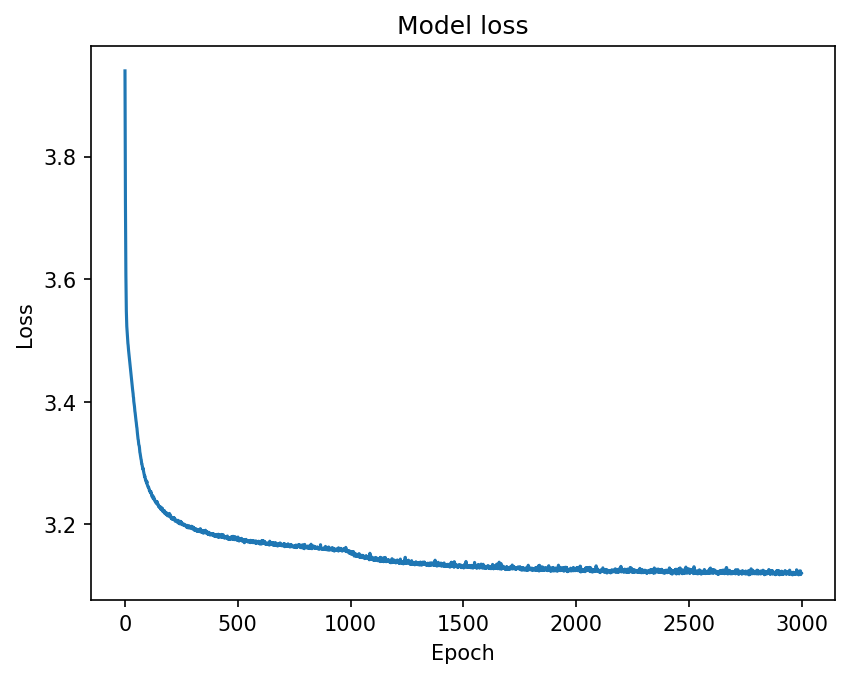

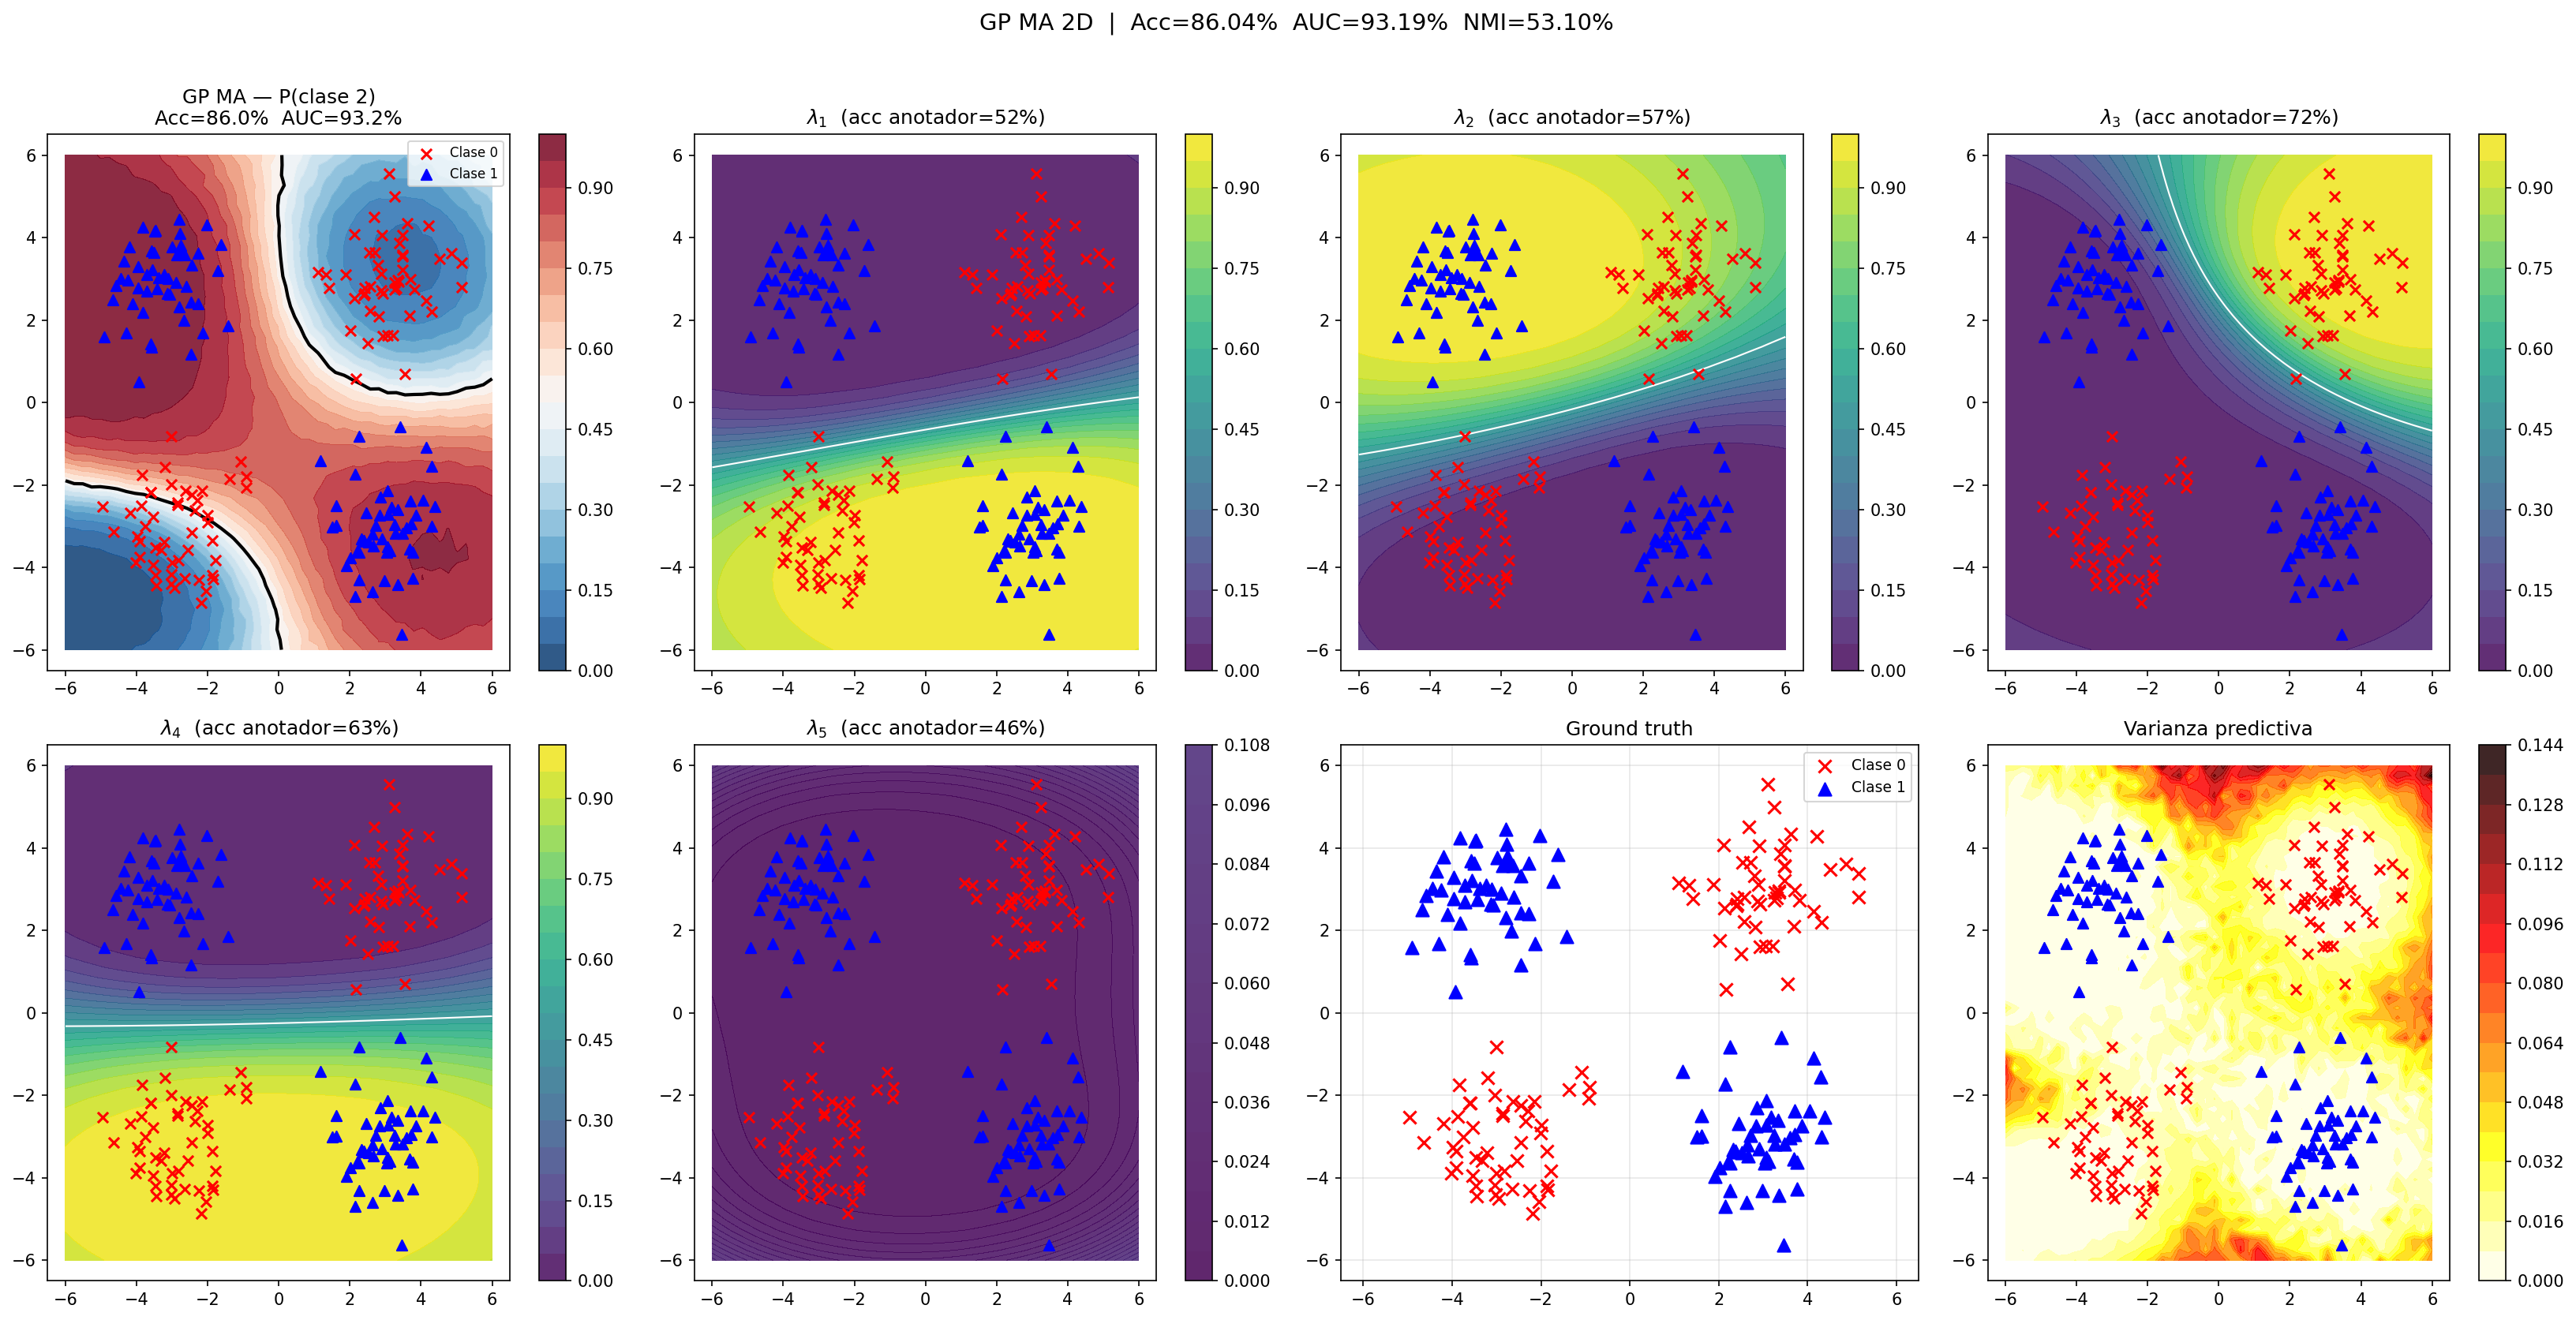

Acc=86.04%  |  AUC=93.19%  |  NMI=53.10%


In [21]:
from IPython.display import Image, display
import numpy as np

display(Image('/tmp/training_loss.png'))
display(Image('/tmp/resultados_2d.png'))

acc, auc, nmi = np.load("/tmp/metrics.npy")
print(f"Acc={acc*100:.2f}%  |  AUC={auc*100:.2f}%  |  NMI={nmi*100:.2f}%")